In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the raw dataset
cr_loan = pd.read_csv('cr_loan2.csv')

In [99]:
# Basic exploration
print("Shape:", cr_loan.shape)
print("\nColumn types:\n", cr_loan.dtypes)
print("\nFirst 5 rows:\n", cr_loan.head())
print("\nBasic stats:\n", cr_loan.describe())

Shape: (32581, 12)

Column types:
 person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

First 5 rows:
    person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loa

In [101]:
# Checking the person_emp_length column
print(cr_loan['person_emp_length'].describe())

# Checking loan_status values
print("\nloan_status unique values:", cr_loan['loan_status'].unique())
print("Default rate:", cr_loan['loan_status'].mean())

count    31686.000000
mean         4.789686
std          4.142630
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64

loan_status unique values: [1 0]
Default rate: 0.21816396059052823


In [103]:
#Crosstab — default rate by home ownership
print(pd.crosstab(cr_loan['person_home_ownership'], 
                  cr_loan['loan_status'], 
                  values=cr_loan['loan_int_rate'], 
                  aggfunc='mean').round(2))

loan_status                0      1
person_home_ownership              
MORTGAGE               10.06  13.43
OTHER                  11.41  13.56
OWN                    10.75  12.24
RENT                   10.75  12.97


In [105]:
#Finding outliers using crosstab
print(pd.crosstab(cr_loan['person_home_ownership'],
                  cr_loan['loan_status'],
                  values=cr_loan['person_emp_length'],
                  aggfunc='max'))

loan_status                0      1
person_home_ownership              
MORTGAGE               123.0   34.0
OTHER                   24.0   11.0
OWN                     31.0   17.0
RENT                    41.0  123.0


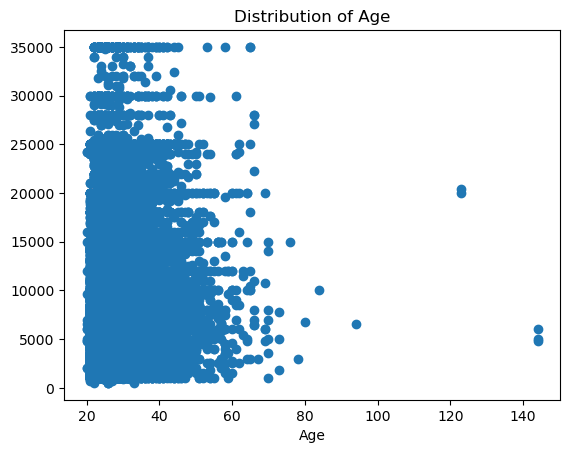

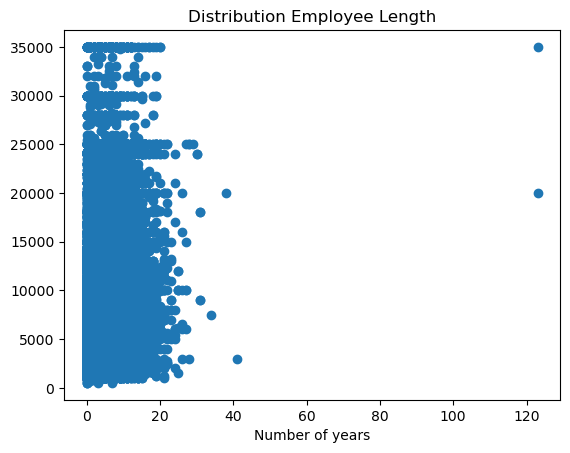

In [107]:
# EXERCISE 6: Visualize the outliers


plt.scatter(x=cr_loan['person_age'], y = cr_loan['loan_amnt'])
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.show()

plt.scatter(x=cr_loan['person_emp_length'], y = cr_loan['loan_amnt'])
plt.title('Distribution Employee Length')
plt.xlabel('Number of years')
plt.show()


In [108]:
# Check missing values
print(cr_loan.isnull().sum())

# Checking outliers
print("\nMax age:", cr_loan['person_age'].max())
print("Max emp_length:", cr_loan['person_emp_length'].max())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Max age: 144
Max emp_length: 123.0


In [109]:
#Dropping rows where employment length is still missing
cr_loan.dropna(subset=['person_emp_length'], inplace=True)
cr_loan['loan_int_rate'].fillna((cr_loan['loan_int_rate'].mean()), inplace = True)



#Verifying
print(cr_loan.isnull().sum())
print("Final shape:", cr_loan.shape)

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64
Final shape: (31686, 12)


In [110]:
cr_loan = cr_loan.drop(cr_loan[cr_loan['person_age'] >= 90].index)
cr_loan = cr_loan.drop(cr_loan[cr_loan['person_emp_length'] >= 60].index)

print(cr_loan.shape)


(31678, 12)


In [114]:
# One-hot encode all categorical columns
cr_loan_prep = pd.get_dummies(cr_loan, drop_first=True)

print("Shape after encoding:", cr_loan_prep.shape)
print(cr_loan_prep.columns.tolist())

Shape after encoding: (31678, 23)
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_Y']


In [117]:
from sklearn.model_selection import train_test_split

# Separate features (X) from target (y)
X = cr_loan_prep.drop('loan_status', axis=1)
y = cr_loan_prep['loan_status']

# Split - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)


In [119]:
from sklearn.linear_model import LogisticRegression

# Create and train the model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [121]:
# Predict probability of default for each applicant
pred_probs = lr.predict_proba(X_test)[:, 1]

# Predict the actual class (0 or 1) using 0.5 threshold
preds = lr.predict(X_test)

print("Sample probabilities:", pred_probs[:5].round(3))
print("Sample predictions:", preds[:5])
print("Actual values:", y_test.values[:5])

Sample probabilities: [0.074 0.047 0.156 0.159 0.209]
Sample predictions: [0 0 0 0 0]
Actual values: [0 0 0 1 0]


In [123]:
from sklearn.metrics import classification_report, roc_auc_score

print("ROC-AUC Score:", roc_auc_score(y_test, pred_probs).round(3))
print("\nClassification Report:\n", classification_report(y_test, preds))

ROC-AUC Score: 0.763

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.98      0.89      4928
           1       0.75      0.16      0.26      1408

    accuracy                           0.80      6336
   macro avg       0.78      0.57      0.57      6336
weighted avg       0.79      0.80      0.75      6336



In [125]:
!pip install xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                    random_state=42, eval_metric='logloss')

xgb.fit(X_train, y_train)

print("XGBoost trained!")

XGBoost trained!


In [127]:
xgb_preds = xgb.predict(X_test)
xgb_probs = xgb.predict_proba(X_test)[:, 1]

#Rough testing
print (f'probability values: {xgb_probs[:5].round(3)}')
print (f'predicted values: {xgb_preds[:5]}')
print (f'actual values: {y_test.values[:5]}')

#Scoring the accuracy
print("XGBoost ROC-AUC:", roc_auc_score(y_test, xgb_probs).round(3))
print(classification_report(y_test, xgb_preds))

probability values: [0.002 0.027 0.    0.977 0.135]
predicted values: [0 0 0 1 0]
actual values: [0 0 0 1 0]
XGBoost ROC-AUC: 0.946
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4928
           1       0.97      0.73      0.83      1408

    accuracy                           0.93      6336
   macro avg       0.95      0.86      0.89      6336
weighted avg       0.94      0.93      0.93      6336



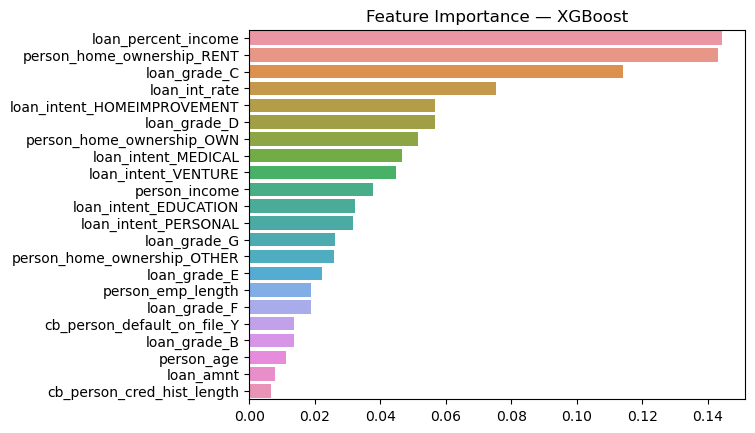

In [128]:
import seaborn as sns

xgb_imp = pd.Series(xgb.feature_importances_, index=X_train.columns)
xgb_imp = xgb_imp.sort_values(ascending = False)

sns.barplot(x=xgb_imp.values, y=xgb_imp.index)
plt.title('Feature Importance — XGBoost')
plt.show()

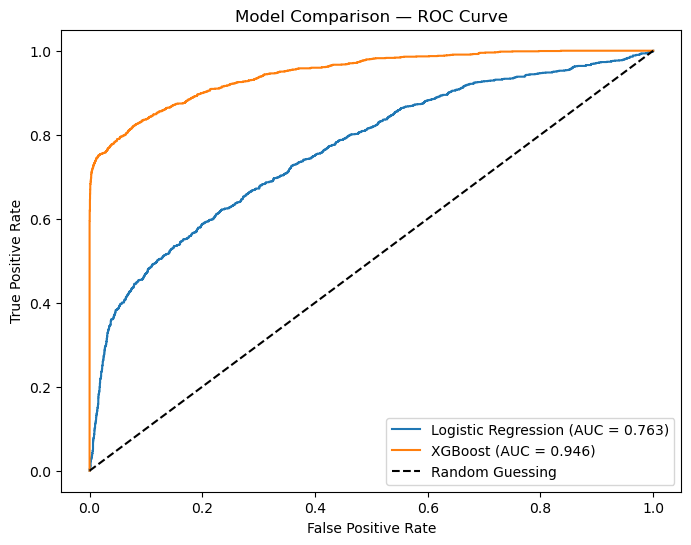

In [129]:
from sklearn.metrics import roc_curve

# Get ROC curve points for both models
lr_fpr, lr_tpr, _ = roc_curve(y_test, pred_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, pred_probs).round(3)})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test, xgb_probs).round(3)})')
plt.plot([0,1], [0,1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model Comparison — ROC Curve')
plt.legend()
plt.show()

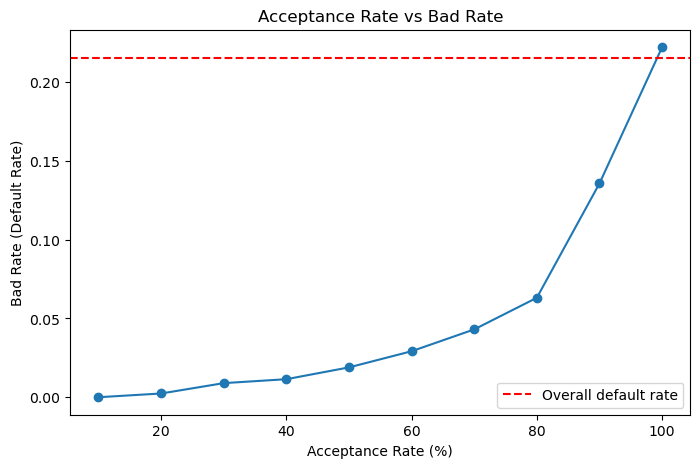

In [134]:
# Create a dataframe with actual values and predicted probabilities
accept_df = pd.DataFrame({'true': y_test.values, 
                          'prob': xgb_probs})

# Sort by predicted probability — safest applicants first
accept_df = accept_df.sort_values('prob', ascending=True)

# Calculate bad rate at each acceptance threshold
thresholds = np.arange(0.1, 1.01, 0.1)
bad_rates = []

for thresh in thresholds:
    accepted = accept_df.head(int(len(accept_df) * thresh))
    bad_rate = accepted['true'].mean()
    bad_rates.append(bad_rate)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds * 100, bad_rates, marker='o')
plt.xlabel('Acceptance Rate (%)')
plt.ylabel('Bad Rate (Default Rate)')
plt.title('Acceptance Rate vs Bad Rate')
plt.axhline(y=cr_loan['loan_status'].mean(), color='red', 
            linestyle='--', label='Overall default rate')
plt.legend()
plt.show()

In [131]:

loss_df = pd.DataFrame({
    'loan_amnt': X_test['loan_amnt'].values,
    'prob': xgb_probs,
    'true': y_test.values})

# Calculate expected loss per applicant
loss_df['EL'] = loss_df['prob'] * 0.45 * loss_df['loan_amnt']

# Total expected loss with the model (only approve the safest 50%)
approved = loss_df.sort_values('prob').head(int(len(loss_df) * 0.5))
model_loss = approved['EL'].sum()

# Total expected loss WITHOUT model (approve everyone)
no_model_loss = loss_df['EL'].sum()

# Savings
savings = no_model_loss - model_loss

print(f"Expected Loss without model: ${no_model_loss.round(0)}")
print(f"Expected Loss with model:    ${model_loss.round(0)}")
print(f"Money saved by using model:  ${savings.round(0)}")

Expected Loss without model: $6685953.0
Expected Loss with model:    $334162.0
Money saved by using model:  $6351791.0
